Step 1: Identify the Business Problem
From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.
Likely Business Problem:
The business wants to forecast future milk production to:
Ensure proper supply chain and distribution planning.
Manage inventory and storage efficiently.
Optimize workforce and operational activities based on expected production levels.
Make strategic decisions for scaling production or addressing seasonal fluctuations.

Step 2: Define the Objective
Objective Statement:
The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.

Steps to include;
✅ Assignment Tasks
1.Exploratory Data Analysis (EDA)
oVisualize trends, seasonality, and anomalies in the milk production data.
oCheck for any missing values or outliers.
oNormalize or scale the data for neural network models.
2.Data Preparation for Deep Learning
oCreate input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
oSplit data into training, validation, and test sets.
oReshape data for model input dimensions.
3.Model Building
oBuild three separate models:
Basic RNN
LSTM
GRU
oTune hyperparameters (e.g., window size, number of units, batch size, epochs).
oUse appropriate loss functions and optimizers.
4.Model Evaluation
oPlot predictions vs. actual values.
oCalculate forecasting metrics: RMSE, MAE, MAPE.
oCompare the performance of RNN, LSTM, and GRU.
5.Prediction and Visualization
oForecast milk production for the next 12 months.
oVisualize the predicted trend with uncertainty or confidence intervals if possible.
6.Business Insights
oInterpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.


1.Exploratory Data Analysis (EDA)
oVisualize trends, seasonality, and anomalies in the milk production data.
oCheck for any missing values or outliers.
oNormalize or scale the data for neural network models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("monthly_milk_production.csv")

In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [5]:
df.tail()

,Date,Production
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797
167,1975-12,843


In [6]:
df.shape

(168, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [8]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [9]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['Date', 'Production'], dtype='object')

In [14]:
df.columns=["Month","Milk_Production"]

In [15]:
df.set_index("Month", inplace=True)

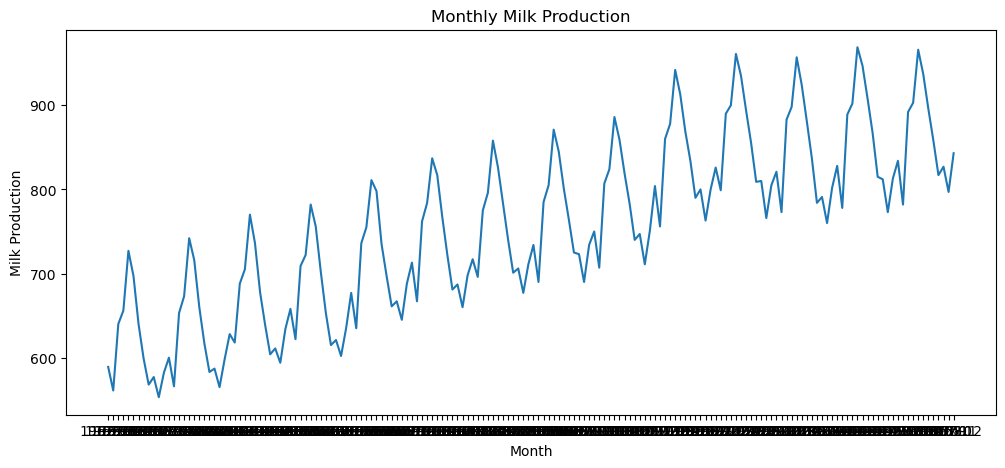

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df["Milk_Production"])
plt.title("Monthly Milk Production")
plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.show()

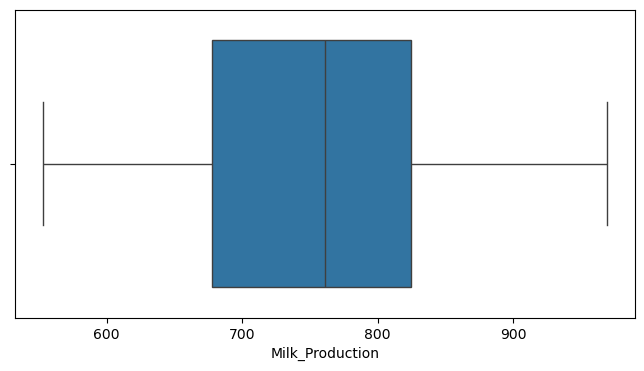

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Milk_Production"])
plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

2.Data Preparation for Deep Learning
oCreate input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
oSplit data into training, validation, and test sets.
oReshape data for model input dimensions.

In [20]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [21]:
def create_dataset(dataset, time_step=12):
    X, y = [], []

    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])

    return np.array(X), np.array(y)

In [22]:
time_step = 12

X_train, y_train = create_dataset(train_data, time_step)

In [23]:
X_test, y_test = create_dataset(test_data, time_step)

In [24]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(122, 12, 1)
(122, 1)
(22, 12, 1)
(22, 1)


In [25]:
print(X_train[0])
print(y_train[0])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]
 [0.34615385]
 [0.20913462]
 [0.11057692]
 [0.03605769]
 [0.05769231]
 [0.        ]
 [0.06971154]]
[0.11298077]


3.Model Building
oBuild three separate models:
Basic RNN
LSTM
GRU
oTune hyperparameters (e.g., window size, number of units, batch size, epochs).
oUse appropriate loss functions and optimizer

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [27]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(time_step,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

C:\Users\Akshay\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0907 - val_loss: 0.0225
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0274 - val_loss: 0.0261
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0148 - val_loss: 0.0334
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0084 - val_loss: 0.0053
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062 - val_loss: 0.0115
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - val_loss: 0.0111
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0032 - val_loss: 0.0061
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0028 - val_loss: 0.0044
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0021 - val_loss: 0.0026
E

In [28]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(time_step,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0744 - val_loss: 0.0407
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0312 - val_loss: 0.0372
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0271 - val_loss: 0.0297
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0243 - val_loss: 0.0354
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0245 - val_loss: 0.0252
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0224 - val_loss: 0.0251
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0221 - val_loss: 0.0256
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219 - val_loss: 0.0246
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0218 - val_loss: 0.0256
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0215 - val_loss: 0.0234
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0211 - val_loss: 0.0233
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0208 - val_loss: 0.0243
E

In [29]:
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(time_step,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.1172 - val_loss: 0.1041
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0311 - val_loss: 0.0226
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0310 - val_loss: 0.0230
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0227 - val_loss: 0.0388
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0229 - val_loss: 0.0429
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0220 - val_loss: 0.0317
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0204 - val_loss: 0.0267
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0202 - val_loss: 0.0252
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0195 - val_loss: 0.0265
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0190 - val_loss: 0.0274
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0186 - val_loss: 0.0252
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0180 - val_loss: 0.0247
E

In [30]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,955 (31.08 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,304 (20.72 KB)

In [31]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [32]:
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,005 (93.77 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,004 (62.52 KB)

4.Model Evaluation
oPlot predictions vs. actual values.
oCalculate forecasting metrics: RMSE, MAE, MAPE.
oCompare the performance of RNN, LSTM, and GRU.

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [35]:
rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


In [36]:
y_test_inv = scaler.inverse_transform(y_test)

rnn_pred_inv = scaler.inverse_transform(rnn_pred)

lstm_pred_inv = scaler.inverse_transform(lstm_pred)

gru_pred_inv = scaler.inverse_transform(gru_pred)

In [37]:
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return rmse, mae, mape

In [38]:
rnn_rmse, rnn_mae, rnn_mape = evaluate_model(y_test_inv, rnn_pred_inv)

lstm_rmse, lstm_mae, lstm_mape = evaluate_model(y_test_inv, lstm_pred_inv)

gru_rmse, gru_mae, gru_mape = evaluate_model(y_test_inv, gru_pred_inv)

In [39]:
print("RNN")
print("RMSE :", rnn_rmse)
print("MAE  :", rnn_mae)
print("MAPE :", rnn_mape)

print("\nLSTM")
print("RMSE :", lstm_rmse)
print("MAE  :", lstm_mae)
print("MAPE :", lstm_mape)

print("\nGRU")
print("RMSE :", gru_rmse)
print("MAE  :", gru_mae)
print("MAPE :", gru_mape)

RNN
RMSE : 11.814080951774201
MAE  : 9.785971901633513
MAPE : 1.1273883232515707

LSTM
RMSE : 25.853902566349333
MAE  : 21.939289439808228
MAPE : 2.5579772517209087

GRU
RMSE : 46.61556155680024
MAE  : 39.3615889115767
MAPE : 4.539782430927676


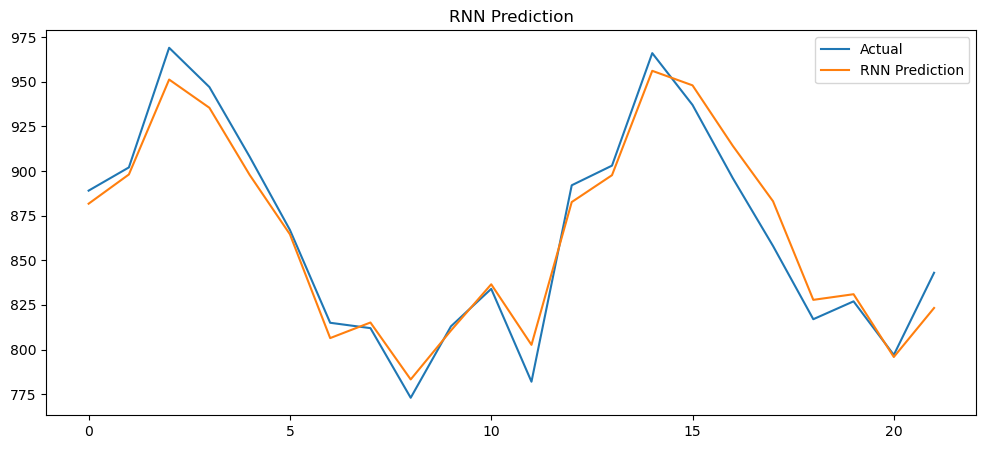

In [40]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv, label="Actual")

plt.plot(rnn_pred_inv, label="RNN Prediction")

plt.legend()

plt.title("RNN Prediction")

plt.show()

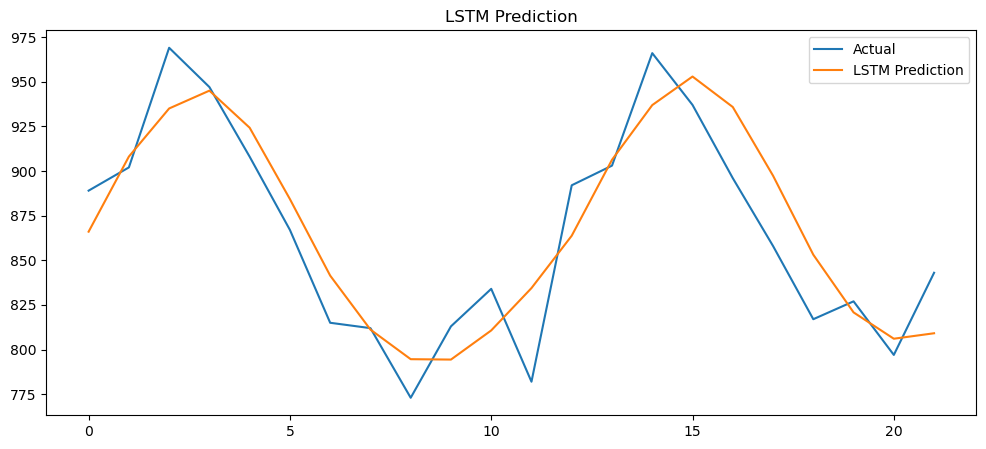

In [41]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv, label="Actual")

plt.plot(lstm_pred_inv, label="LSTM Prediction")

plt.legend()

plt.title("LSTM Prediction")

plt.show()

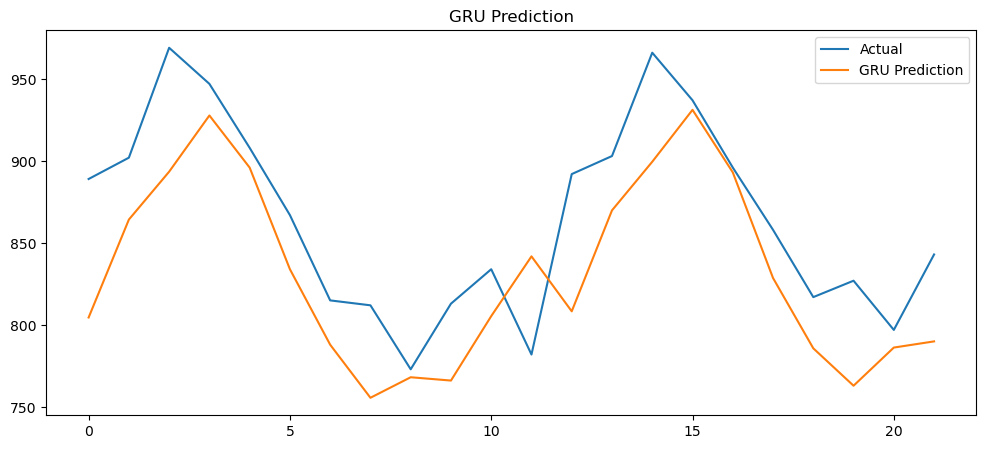

In [42]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv, label="Actual")

plt.plot(gru_pred_inv, label="GRU Prediction")

plt.legend()

plt.title("GRU Prediction")

plt.show()

5.Prediction and Visualization
oForecast milk production for the next 12 months.
oVisualize the predicted trend with uncertainty or confidence intervals if possible.

In [43]:
future_input = scaled_data[-time_step:].reshape(1, time_step, 1)

future_predictions = []

for i in range(12):

    pred = lstm_model.predict(future_input, verbose=0)

    future_predictions.append(pred[0][0])

    future_input = np.append(future_input[:,1:,:],
                             [[[pred[0][0]]]],
                             axis=1)

In [44]:
future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions = scaler.inverse_transform(future_predictions)

In [45]:
print("Forecast for Next 12 Months:")

for i, value in enumerate(future_predictions):
    print(f"Month {i+1}: {value[0]:.2f}")

Forecast for Next 12 Months:
Month 1: 827.79
Month 2: 842.54
Month 3: 883.51
Month 4: 911.62
Month 5: 937.08
Month 6: 937.55
Month 7: 922.58
Month 8: 898.34
Month 9: 872.13
Month 10: 855.24
Month 11: 839.12
Month 12: 840.17


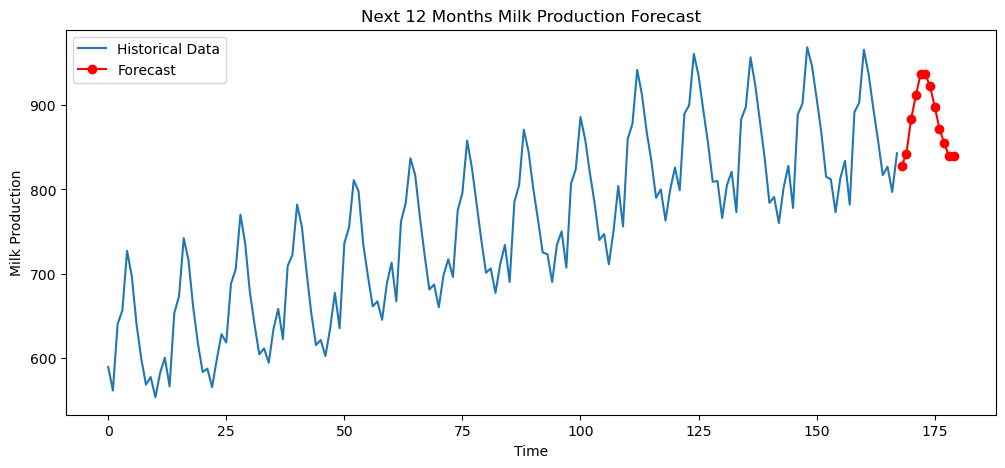

In [46]:
plt.figure(figsize=(12,5))

plt.plot(range(len(df)),
         df["Milk_Production"],
         label="Historical Data")

plt.plot(range(len(df), len(df)+12),
         future_predictions,
         marker='o',
         color='red',
         label="Forecast")

plt.title("Next 12 Months Milk Production Forecast")

plt.xlabel("Time")

plt.ylabel("Milk Production")

plt.legend()

plt.show()

6.Business Insights
oInterpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

# Business Insights

1. The forecasting models help predict future monthly milk production, allowing the dairy business to plan operations more effectively.

2. Accurate forecasts support inventory and storage management by reducing the risk of overproduction or shortages.

3. Forecasting enables better workforce planning and resource allocation during seasonal demand changes.

4. Comparing RNN, LSTM, and GRU models helps identify the most accurate model for production forecasting. The model with the lowest RMSE, MAE, and MAPE should be selected for deployment.

5. The 12-month forecast provides valuable insights for long-term production planning, budgeting, supply chain management, and strategic business decisions.